In [1]:
import numpy as np
prices = [ 10, 15, 20, 25, 30, 35, 60, 65, 70, 75, 80, 85, 90, 95, 100, 110]


# 1. Loop-based version
taxed_prices_loop = []

for price in prices:
    taxed_prices_loop.append(price * 1.08)

print("Loop version:")
print(taxed_prices_loop)


# 2. NumPy vectorized version
prices_array = np.array(prices)

taxed_prices_numpy = prices_array * 1.08

print("\nNumPy version:")
print(taxed_prices_numpy)
print("\nResults are same:")
print(np.allclose(taxed_prices_loop, taxed_prices_numpy))


# 3. Boolean masking
threshold = 50

above_threshold = taxed_prices_numpy[taxed_prices_numpy > threshold]

print("\nTaxed prices above 50:")
print(above_threshold)


# 4. 2D array
data = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])

row_sums = data.sum(axis=1)
column_sums = data.sum(axis=0)

print("\nRow sums:")
print(row_sums)

print("\nColumn sums:")
print(column_sums)


Loop version:
[10.8, 16.200000000000003, 21.6, 27.0, 32.400000000000006, 37.800000000000004, 64.80000000000001, 70.2, 75.60000000000001, 81.0, 86.4, 91.80000000000001, 97.2, 102.60000000000001, 108.0, 118.80000000000001]

NumPy version:
[ 10.8  16.2  21.6  27.   32.4  37.8  64.8  70.2  75.6  81.   86.4  91.8
  97.2 102.6 108.  118.8]

Results are same:
True

Taxed prices above 50:
[ 64.8  70.2  75.6  81.   86.4  91.8  97.2 102.6 108.  118.8]

Row sums:
[100 260 420]

Column sums:
[150 180 210 240]


In [2]:

#Exercise 2
import pandas as pd
employees = pd.DataFrame({
    "name": [
        "Pavan", "Ravi", "Sai", "Kiran", "Arjun",
        "Rahul", "Vijay", "Manoj", "Suresh", "Naveen",
        "Teja", "Praveen", "Rohit", "Anil", "Varun"
    ],

    "department": [
        "AI", "HR", "AI", "Sales", "HR",
        "AI", "Sales", "AI", "HR", "Sales",
        "AI", "HR", "Sales", "AI", "Sales"
    ],

    "salary": [
        70000, 50000, 80000, 60000, 55000,
        75000, 65000, 72000, 58000, 68000,
        90000, 52000, 70000, 85000, 62000
    ],

    "years_experience": [
        2, 3, 4, 2, 5,
        3, 4, 5, 2, 6,
        7, 3, 5, 6, 2
    ]
})
employees.to_csv("employees.csv", index=False)
df = pd.read_csv("employees.csv")
print(df)
print("\nINFO:")
df.info()
print("\nDESCRIBE:")
print(df.describe())
ai_1 = df[df["department"] == "AI"]
ai_2 = df.query("department == 'AI'")
print("\nBoolean filtering:")
print(ai_1)
print("\nQuery filtering:")
print(ai_2)
summary = (
    df.groupby("department")
      .agg(
          average_salary=("salary", "mean"),
          headcount=("name", "count")
      )
      .sort_values("average_salary", ascending=False)
)

print("\nDepartment summary:")
print(summary)


       name department  salary  years_experience
0     Pavan         AI   70000                 2
1      Ravi         HR   50000                 3
2       Sai         AI   80000                 4
3     Kiran      Sales   60000                 2
4     Arjun         HR   55000                 5
5     Rahul         AI   75000                 3
6     Vijay      Sales   65000                 4
7     Manoj         AI   72000                 5
8    Suresh         HR   58000                 2
9    Naveen      Sales   68000                 6
10     Teja         AI   90000                 7
11  Praveen         HR   52000                 3
12    Rohit      Sales   70000                 5
13     Anil         AI   85000                 6
14    Varun      Sales   62000                 2

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name      

In [3]:
##exercise 3
import pandas as pd
import numpy as np
departments = pd.DataFrame({
    "department": ["AI", "HR", "Sales"],
    "department_budget": [1000000, 500000, 700000]
})

print("Departments:")
print(departments)

# 1. INNER JOIN
inner_join = pd.merge(
    df,
    departments,
    on="department",
    how="inner"
)

print("\nInner Join:")
print(inner_join)


# 2. Add unmatched employee
df.loc[len(df)] = [
    "Karthik",
    "Legal",
    55000,
    3
]

print("\nEmployees after adding Karthik:")
print(df)
left_join = pd.merge(
    df,
    departments,
    on="department",
    how="left"
)

print("\nLeft Join:")
print(left_join)

# 3. Introduce missing valuesdf.loc[0, "salary"] = np.nan
df.loc[1, "years_experience"] = np.nan

print("\nDataFrame with missing values:")
print(df)
print("\nMissing values:")
print(df.isna().sum())

# 4. Handle missing values
df["salary"] = df["salary"].fillna(df["salary"].mean())
df["years_experience"] = df["years_experience"].fillna(
    df["years_experience"].mean()
)

print("\nAfter handling missing values:")
print(df)


Departments:
  department  department_budget
0         AI            1000000
1         HR             500000
2      Sales             700000

Inner Join:
       name department  salary  years_experience  department_budget
0     Pavan         AI   70000                 2            1000000
1      Ravi         HR   50000                 3             500000
2       Sai         AI   80000                 4            1000000
3     Kiran      Sales   60000                 2             700000
4     Arjun         HR   55000                 5             500000
5     Rahul         AI   75000                 3            1000000
6     Vijay      Sales   65000                 4             700000
7     Manoj         AI   72000                 5            1000000
8    Suresh         HR   58000                 2             500000
9    Naveen      Sales   68000                 6             700000
10     Teja         AI   90000                 7            1000000
11  Praveen         HR   52000

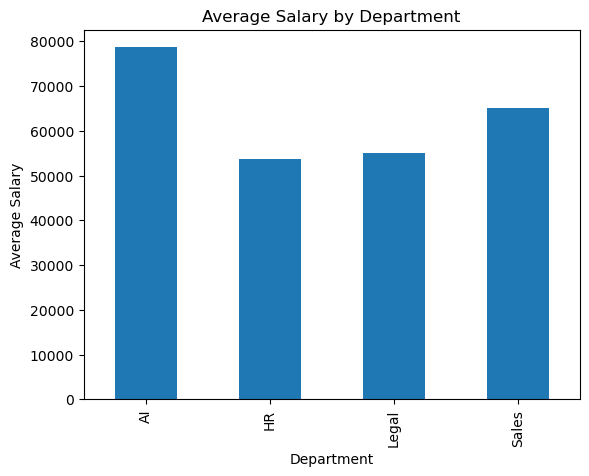

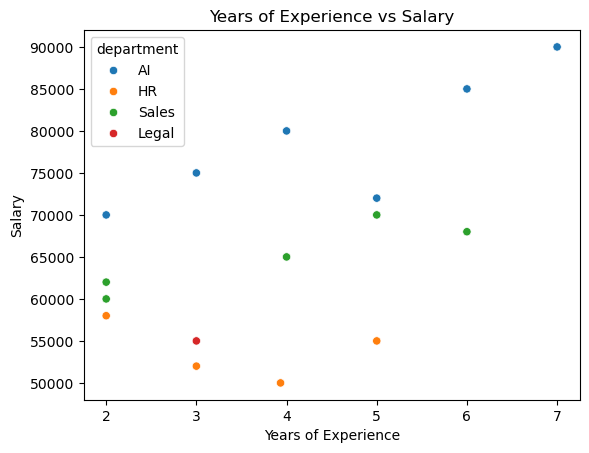

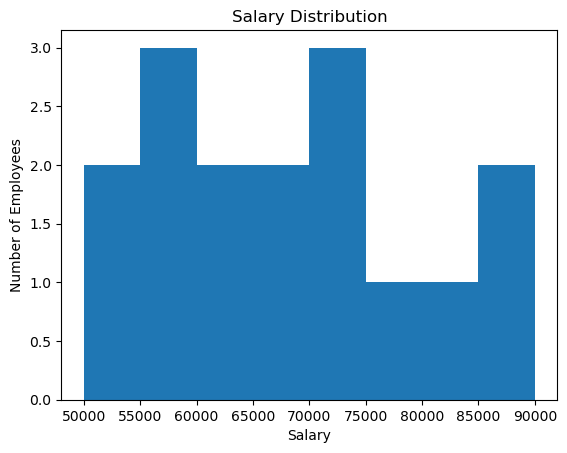

In [4]:

##exercise 4

import matplotlib.pyplot as plt
import seaborn as sns

# 1. BAR CHART
avg_salary = (
    df.groupby("department")["salary"]
      .mean()
)

avg_salary.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()

# 2. SCATTER PLOT
sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary",
    hue="department"
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

# 3. HISTOGRAM
plt.hist(df["salary"], bins=8)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()
